In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json
import _utils

In [2]:
import matplotlib as mpl

In [3]:
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 8

### plotting functions

In [4]:
plt.rcParams['figure.dpi'] = 200

In [5]:
pinkgy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.45, .04)), 
                matplotlib.colormaps["PiYG_r"](np.arange(0.5, 0.85, .04))]), N = 10)

orangy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.45, .04)), 
                matplotlib.colormaps["PuOr_r"](np.arange(0.5, 0.85, .04))]), N = 10)

brown_col = matplotlib.colormaps["BrBG"](np.linspace(0., 0.499, 64))
blue_col = matplotlib.colormaps["RdBu"](np.linspace(0.501, 1, 64))
brownblue_col = np.vstack((brown_col, blue_col))
brbl = LinearSegmentedColormap.from_list('brbl', brownblue_col)

bupu = LinearSegmentedColormap.from_list('bupu', matplotlib.colormaps["BuPu"](np.arange(0, 1.1, .1)), N = 10)
oranges = LinearSegmentedColormap.from_list('oranges', matplotlib.colormaps["Oranges"](np.arange(0, 1.1, .1)), N = 9)
reds = LinearSegmentedColormap.from_list('reds', matplotlib.colormaps["Reds"](np.arange(0, 1.1, .1)), N = 11)

In [6]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "white", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.7, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 16)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.7, location = "bottom")

    ax.set_facecolor(na_col)
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
    return(p)

### read in data

In [7]:
start = 1979
end = 2020

In [8]:
dir = "../mnt_processed_data/"

#### obs

In [39]:
cpc_trend = _utils.read_trends(dir, "cpc", "rx1day", start, end)
gpcc_trend = _utils.read_trends(dir, "gpcc", "mon-p095", start, end)
gpcp_trend = _utils.read_trends(dir, "gpcp", "mon-p095", start, end)
mswep_rx1day_trend = _utils.read_trends(dir, "mswep", "rx1day", start, end)
mswep_mon_trend = _utils.read_trends(dir, "mswep", "mon-p095", start, end)

regen_trend = _utils.read_trends(dir, "regen", "rx1day", 1979, 2016)

#### model ensembles

In [10]:
cmip_day_trends = _utils.read_trends(dir, "cmip", "rx1day", start, end)
cmip_mon_trends = _utils.read_trends(dir, "cmip", "mon-p095", start, end)

spear_day_trends = _utils.read_trends(dir, "spear", "rx1day", start, end)
spear_mon_trends = _utils.read_trends(dir, "spear", "mon-p095", start, end)

mesaclip_day_trends = _utils.read_trends(dir, "mesaclip", "rx1day", start, end)
mesaclip_mon_trends = _utils.read_trends(dir, "mesaclip", "mon-p095", start, end)

In [11]:
model_var_dict = json.load(open(dir+"model_var_dict.json"))

#### check for land mask

In [12]:
## confirm that all obs datasets have every grid cell
print("number of CPC grid cells:",str(xr.where(np.isnan(cpc_trend), 0, 1).sum().values))
print("number of GPCC grid cells:",str(xr.where(np.isnan(gpcc_trend), 0, 1).sum().values))
print("number of GPCP grid cells:",str(xr.where(np.isnan(gpcp_trend), 0, 1).sum().values))
print("number of MSWEP grid cells:",str(xr.where(np.isnan(mswep_mon_trend), 0, 1).sum().values))

number of CPC grid cells: 713
number of GPCC grid cells: 713
number of GPCP grid cells: 713
number of MSWEP grid cells: 713


In [13]:
## confirm that MESACLIP and SPEAR have all land grid cells
print("number of SPEAR grid cells:",str(xr.where(np.isnan(spear_mon_trends.isel(sim = 0)), 0, 1).sum().values))
print("number of MESACLIP grid cells:",str(xr.where(np.isnan(mesaclip_mon_trends.isel(sim = 0)), 0, 1).sum().values))

number of SPEAR grid cells: 713
number of MESACLIP grid cells: 713


In [14]:
cmip_day_mask = xr.where(xr.where(np.isnan(cmip_day_trends), 0, 1).sum(dim = "sim")==len(cmip_day_trends.sim),1,0)
print("number of daily CMIP grid cells in all models:", str((cmip_day_mask == 1).sum().values))

number of daily CMIP grid cells in all models: 693


In [15]:
cmip_mon_mask = xr.where(xr.where(np.isnan(cmip_mon_trends), 0, 1).sum(dim = "sim")==len(cmip_mon_trends.sim),1,0)
print("number of monthly CMIP grid cells in all models:", str((cmip_mon_mask == 1).sum().values))

number of monthly CMIP grid cells in all models: 693


In [16]:
cmip_day_mask.to_netcdf("../processed_data/common_land_mask.nc")

In [17]:
def mask(ds):
    return(xr.where(cmip_day_mask == 1, ds, np.nan))

In [40]:
#### mask all datasets to cmip land grid: 
cpc_trend = mask(cpc_trend)
gpcc_trend = mask(gpcc_trend)
gpcp_trend = mask(gpcp_trend)
mswep_rx1day_trend = mask(mswep_rx1day_trend)
mswep_mon_trend = mask(mswep_mon_trend)
regen_trend = mask(regen_trend)

cmip_day_trends = mask(cmip_day_trends)
cmip_mon_trends = mask(cmip_mon_trends)
spear_day_trends = mask(spear_day_trends)
spear_mon_trends = mask(spear_mon_trends)
mesaclip_day_trends = mask(mesaclip_day_trends)
mesaclip_mon_trends = mask(mesaclip_mon_trends)

#### ecdf results

In [19]:
ecdf_cpc_cmip_day = mask(xr.open_dataarray(dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_cmipsub_day = mask(xr.open_dataarray(dir+"ecdf/cpc_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_spear_day = mask(xr.open_dataarray(dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_mesaclip_day = mask(xr.open_dataarray(dir+"ecdf/cpc_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_gpcc_cmip_mon = mask(xr.open_dataarray(dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_cmipsub_mon = mask(xr.open_dataarray(dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_spear_mon = mask(xr.open_dataarray(dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_mesaclip_mon = mask(xr.open_dataarray(dir+"ecdf/gpcc_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_gpcp_cmip_mon = mask(xr.open_dataarray(dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_cmipsub_mon = mask(xr.open_dataarray(dir+"ecdf/gpcp_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_spear_mon = mask(xr.open_dataarray(dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_mesaclip_mon = mask(xr.open_dataarray(dir+"ecdf/gpcp_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_mswep_cmip_mon = mask(xr.open_dataarray(dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_cmipsub_mon = mask(xr.open_dataarray(dir+"ecdf/mswep_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_spear_mon = mask(xr.open_dataarray(dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_mesaclip_mon = mask(xr.open_dataarray(dir+"ecdf/mswep_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_mswep_cmip_day = mask(xr.open_dataarray(dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_cmipsub_day = mask(xr.open_dataarray(dir+"ecdf/mswep_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_spear_day = mask(xr.open_dataarray(dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_mesaclip_day = mask(xr.open_dataarray(dir+"ecdf/mswep_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))

## Figure 1

In [20]:
N = (cmip_day_mask == 1).sum().values

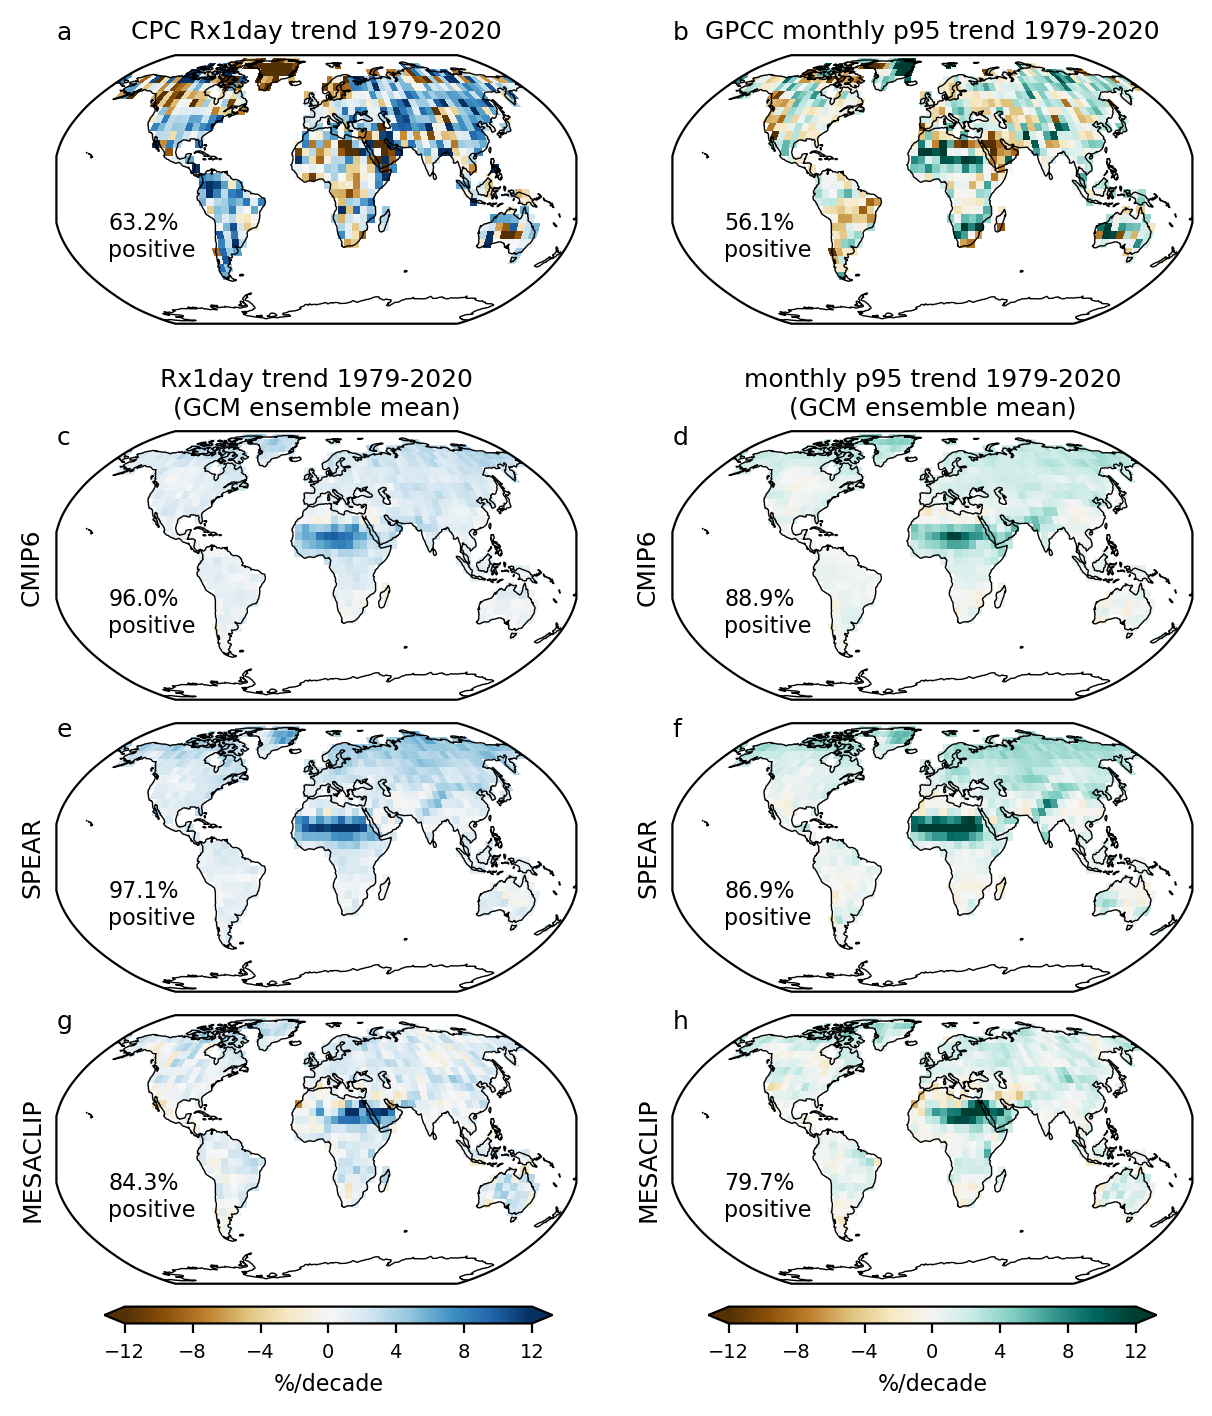

In [21]:
h_tot = 7
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -12
vmax = 12
labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([.04, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend 1979-2020", size = titlesize)
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
plot_map(cpc_trend, cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((cpc_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("Rx1day trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_day_trends.sel(sim = model_var_dict["cmip_day_onevar"]).mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((cmip_day_trends.sel(sim = model_var_dict["cmip_day_onevar"]).mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "e", size = titlesize, transform = ax.transAxes)
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(spear_day_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((spear_day_trends.mean(dim = "sim")>0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, 0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
p = plot_map(mesaclip_day_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mesaclip_day_trends.mean(dim = "sim")>0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)
cbaxes = fig.add_axes([.08, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN
ax = fig.add_axes([.12+w, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend 1979-2020", size = titlesize)
plot_map(gpcc_trend, 
             gpcc_trend.lon, gpcc_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((gpcc_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("monthly p95 trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "d", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_mon_trends.sel(sim = model_var_dict["cmip_mon_onevar"]).mean(dim = "sim"), 
         cmip_mon_trends.lon, cmip_mon_trends.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((cmip_mon_trends.sel(sim = model_var_dict["cmip_mon_onevar"]).mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "f", size = titlesize, transform = ax.transAxes)
plot_map(spear_mon_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((spear_mon_trends.mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.07, w, h], projection = ccrs.Robinson())
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "h", size = titlesize, transform = ax.transAxes)
p = plot_map(mesaclip_mon_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((mesaclip_mon_trends.mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)
cbaxes = fig.add_axes([.15+w, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig1.png", dpi = 600)
plt.savefig("../figures/fig1.pdf")

In [43]:
mswep_rx1day_2016trend = _utils.read_trends(dir, "mswep", "rx1day", start, 2016)

In [44]:
mswep_rx1day_2016trend = mask(mswep_rx1day_2016trend)

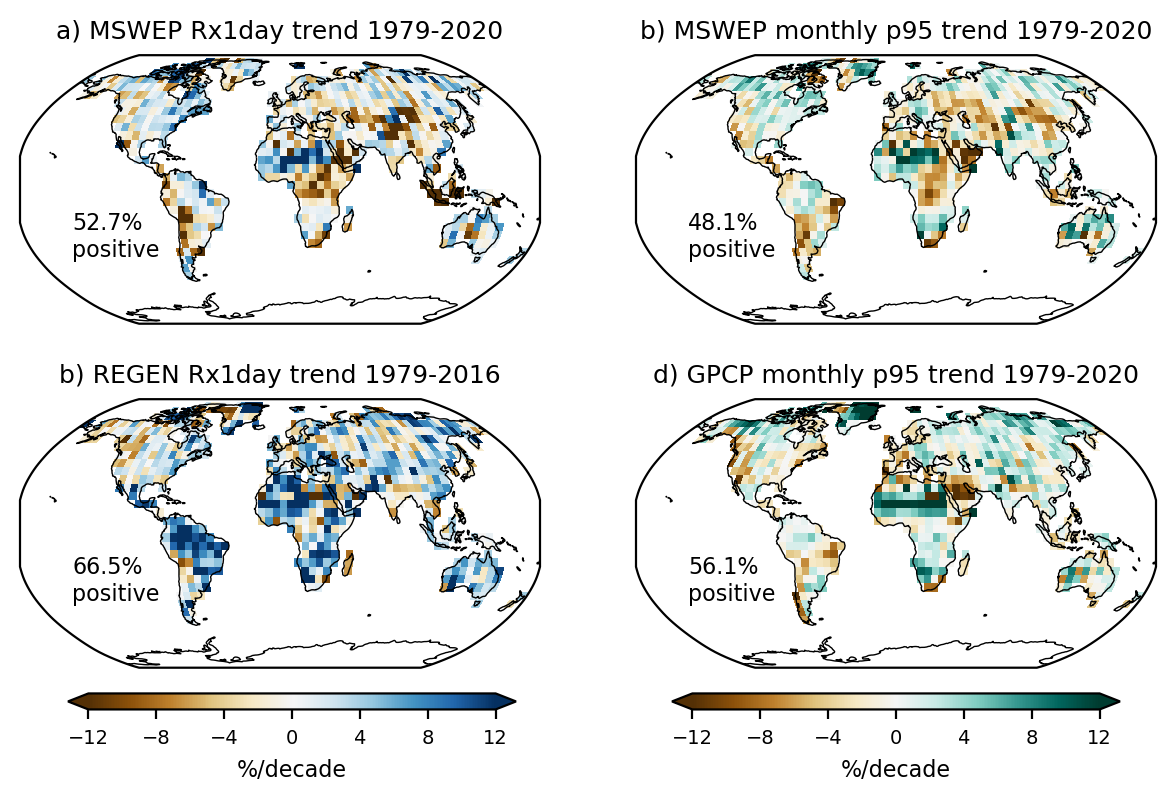

In [102]:
## trends for other observational datasets 
h_tot = 4
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -12
vmax = 12
labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## TOP LEFT
ax = fig.add_axes([.04, h+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("a) MSWEP Rx1day trend 1979-2020", size = titlesize)
p = plot_map(mswep_rx1day_trend, mswep_rx1day_trend.lon, mswep_rx1day_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mswep_rx1day_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, 0.12, w, h], projection = ccrs.Robinson())
ax.set_title("b) REGEN Rx1day trend 1979-2016", size = titlesize)
plot_map(regen_trend, regen_trend.lon, regen_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((regen_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([.08, 0.1, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## TOP RIGHT

ax = fig.add_axes([.12+w, h+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("b) MSWEP monthly p95 trend 1979-2020", size = titlesize)
plot_map(mswep_mon_trend, mswep_mon_trend.lon, mswep_mon_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mswep_mon_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)


ax = fig.add_axes([.12+w, 0.12, w, h], projection = ccrs.Robinson())
ax.set_title("d) GPCP monthly p95 trend 1979-2020", size = titlesize)
p = plot_map(gpcp_trend, gpcp_trend.lon, gpcp_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((gpcc_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([.15+w, 0.1, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_observed_trends.pdf")
plt.savefig("../figures/supp_observed_trends.png", dpi = 600)

## Figure 2

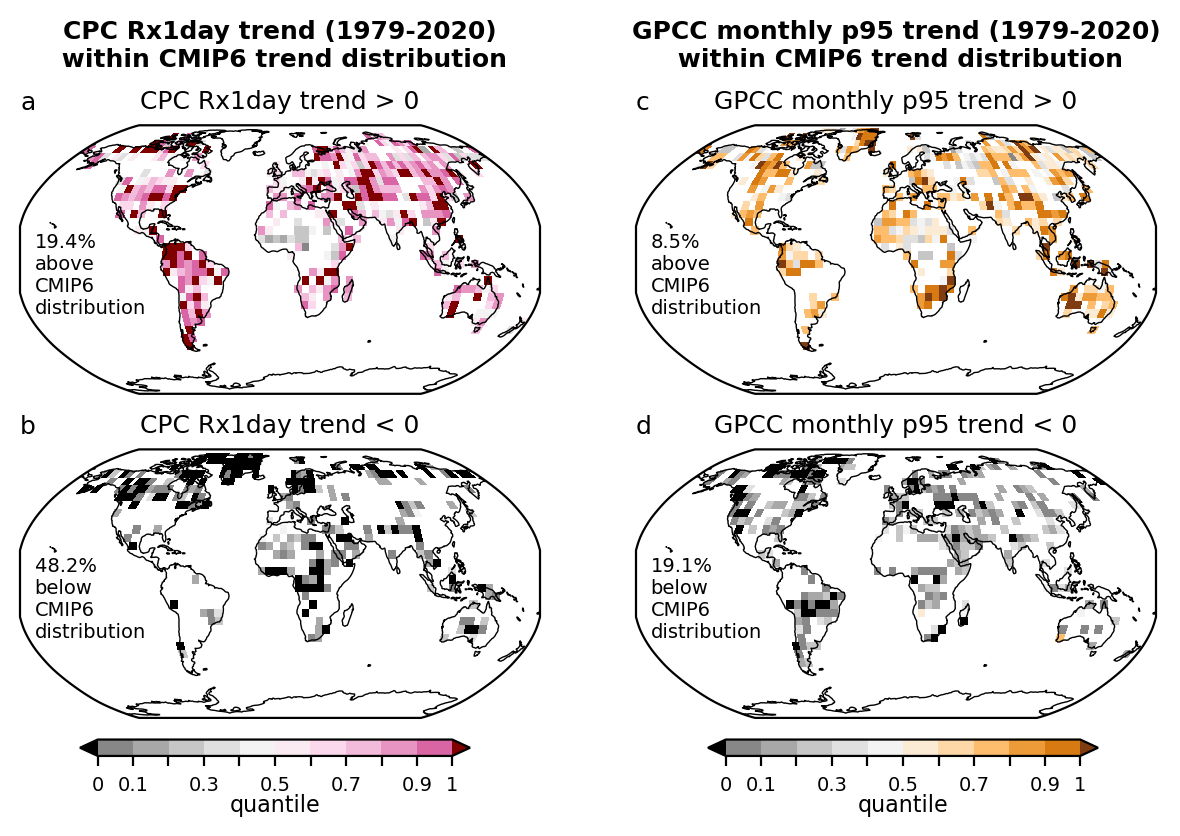

In [95]:
h_tot = 4.1
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([0.04, h+0.1, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
ax.text(0.5, 1.22, "CPC Rx1day trend (1979-2020)\n within CMIP6 trend distribution", ha = 'center', 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_cmipsub_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([0.04, 0.095, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)

p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_cmipsub_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.09, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN 2 - p95 monthly ECDF Maps
ax = fig.add_axes([.12+w, h+0.1, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
ax.text(0, 1.06, "c", size = titlesize, transform = ax.transAxes)
ax.text(0.5, 1.22, "GPCC monthly p95 trend (1979-2020)\n within CMIP6 trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes, ha = 'center')
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_cmipsub_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcc_trend > 0, ecdf_gpcc_cmipsub_mon, np.nan) == 1, 1, 0).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.095, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "d", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_cmipsub_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_cmipsub_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.18+w, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig2.pdf")
plt.savefig("../figures/fig2.png", dpi = 600)

#### SPEAR supplemental comparison

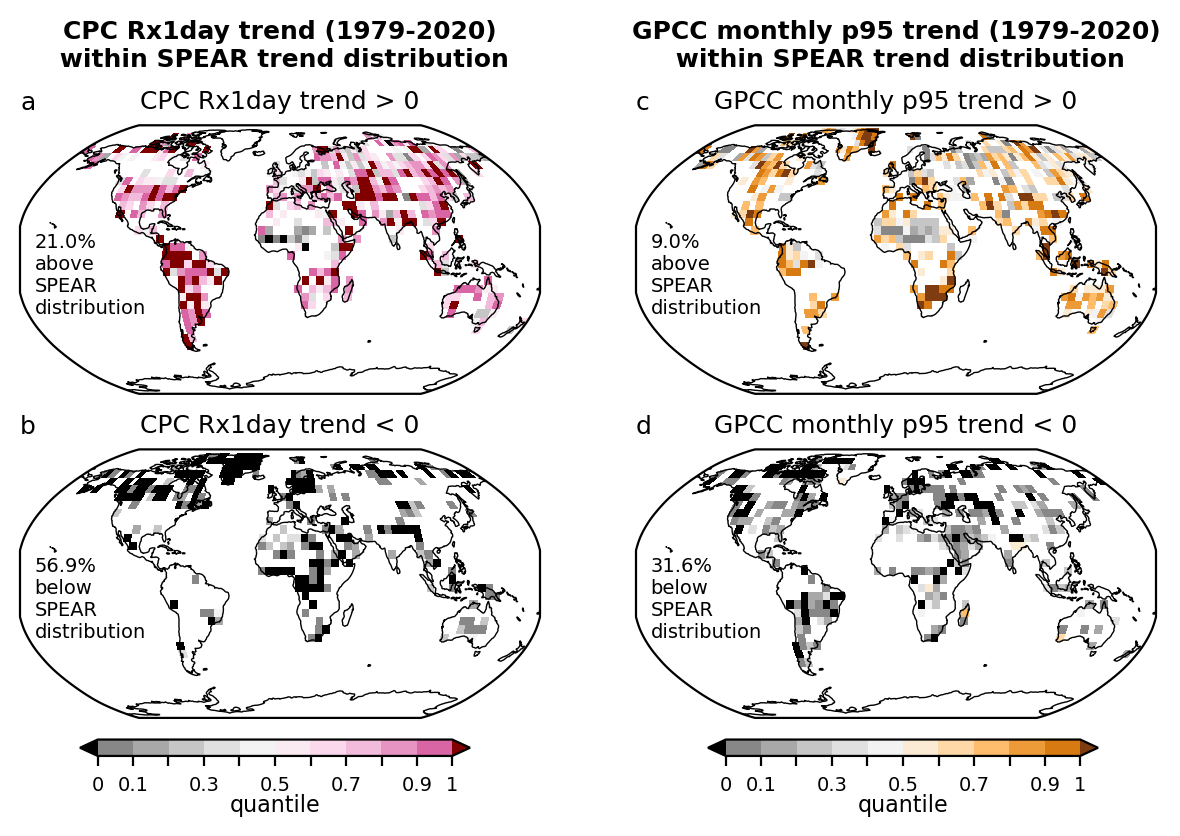

In [97]:
h_tot = 4.1
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([0.04, h+0.1, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
ax.text(0.5, 1.22, "CPC Rx1day trend (1979-2020)\n within SPEAR trend distribution", ha = 'center', 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_spear_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([0.04, 0.095, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_spear_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.09, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN 2 - p95 monthly ECDF Maps
ax = fig.add_axes([.12+w, h+0.1, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
ax.text(0, 1.06, "c", size = titlesize, transform = ax.transAxes)
ax.text(0.5, 1.22, "GPCC monthly p95 trend (1979-2020)\n within SPEAR trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes, ha = 'center')
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_spear_mon, np.nan), 
             ecdf_gpcc_spear_mon.lon, ecdf_gpcc_spear_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = ((xr.where(gpcc_trend > 0, ecdf_gpcc_spear_mon, np.nan) == 1).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.095, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "d", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_spear_mon, np.nan), 
             ecdf_gpcc_spear_mon.lon, ecdf_gpcc_spear_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_spear_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.18+w, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_spear_ecdf.pdf")
plt.savefig("../figures/supp_spear_ecdf.png", dpi = 600)

#### MESACLIP comparison

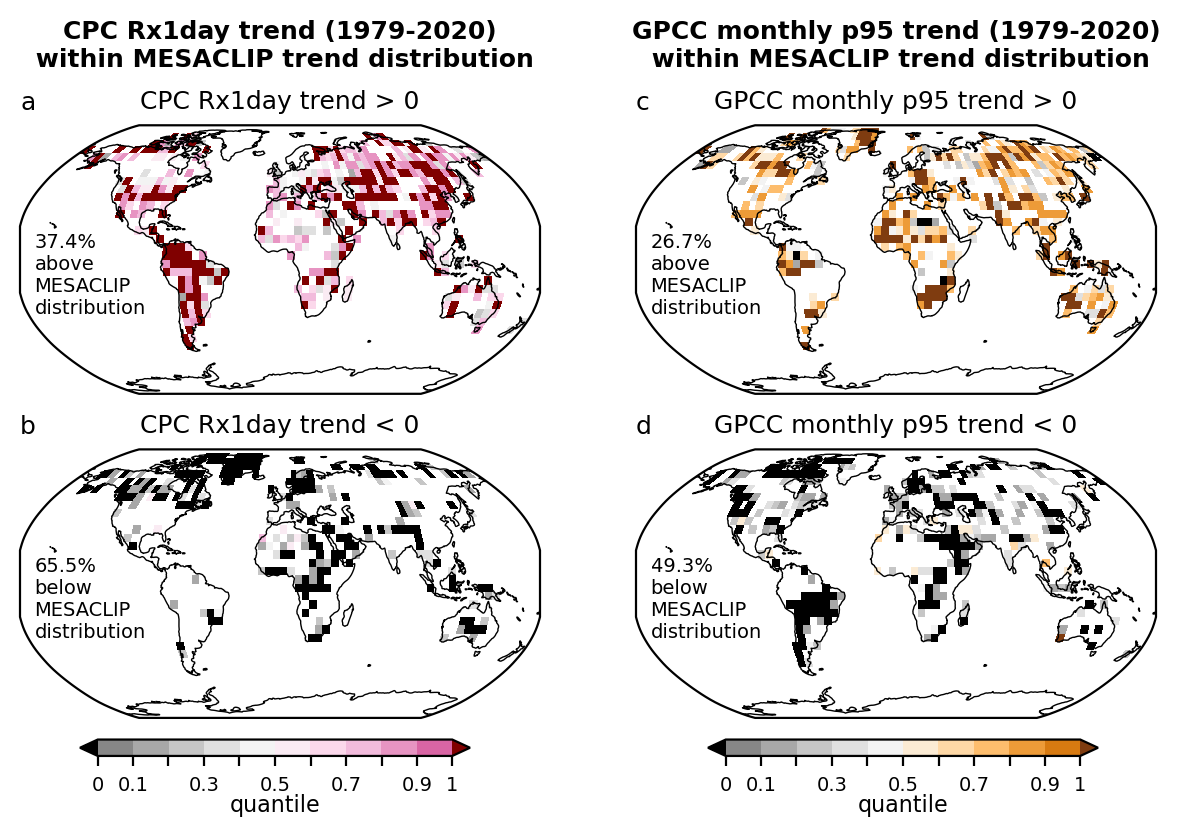

In [99]:
h_tot = 4.1
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([0.04, h+0.1, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
ax.text(0.5, 1.22, "CPC Rx1day trend (1979-2020)\n within MESACLIP trend distribution", ha = 'center', 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_mesaclip_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([0.04, 0.095, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_mesaclip_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.09, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN 2 - p95 monthly ECDF Maps
ax = fig.add_axes([.12+w, h+0.1, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
ax.text(0, 1.06, "c", size = titlesize, transform = ax.transAxes)
ax.text(0.5, 1.22, "GPCC monthly p95 trend (1979-2020)\n within MESACLIP trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes, ha = 'center')
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_mesaclip_mon, np.nan), 
             ecdf_gpcc_mesaclip_mon.lon, ecdf_gpcc_mesaclip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcc_trend > 0, ecdf_gpcc_mesaclip_mon, np.nan) == 1, 1, 0).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.095, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "d", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_mesaclip_mon, np.nan), 
             ecdf_gpcc_mesaclip_mon.lon, ecdf_gpcc_mesaclip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_mesaclip_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.18+w, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_mesaclip_ecdf.pdf")
plt.savefig("../figures/supp_mesaclip_ecdf.png", dpi = 600)

## Figure 3

#### read data:

In [52]:
## read data
ecdf_test_cpc_cmip_day = pd.read_csv(dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_cmipsub_day = pd.read_csv(dir+"ecdf/cpc_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_spear_day = pd.read_csv(dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_mesaclip_day = pd.read_csv(dir+"ecdf/cpc_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_mswep_cmip_day = pd.read_csv(dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_cmipsub_day = pd.read_csv(dir+"ecdf/mswep_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_spear_day = pd.read_csv(dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_mesaclip_day = pd.read_csv(dir+"ecdf/mswep_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_gpcc_cmip_mon = pd.read_csv(dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_cmipsub_mon = pd.read_csv(dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_spear_mon = pd.read_csv(dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_mesaclip_mon = pd.read_csv(dir+"ecdf/gpcc_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_gpcp_cmip_mon = pd.read_csv(dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_cmipsub_mon = pd.read_csv(dir+"ecdf/gpcp_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_spear_mon = pd.read_csv(dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_mesaclip_mon = pd.read_csv(dir+"ecdf/gpcp_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_mswep_cmip_mon = pd.read_csv(dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_cmipsub_mon = pd.read_csv(dir+"ecdf/mswep_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_spear_mon = pd.read_csv(dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_mesaclip_mon = pd.read_csv(dir+"ecdf/mswep_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

In [53]:
ecdf_sub9_mswep_cmip_mon = pd.read_csv(dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcc_cmip_mon = pd.read_csv(dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcp_cmip_mon = pd.read_csv(dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub9_mswep_spear_mon = pd.read_csv(dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcc_spear_mon = pd.read_csv(dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcp_spear_mon = pd.read_csv(dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub30_mswep_cmip_mon = pd.read_csv(dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_gpcc_cmip_mon = pd.read_csv(dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_gpcp_cmip_mon = pd.read_csv(dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)

ecdf_sub9_mswep_cmip_day = pd.read_csv(dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_cpc_cmip_day = pd.read_csv(dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub9_mswep_spear_day = pd.read_csv(dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_cpc_spear_day = pd.read_csv(dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub30_mswep_cmip_day = pd.read_csv(dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_cpc_cmip_day = pd.read_csv(dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)


#### figure plotting: 

In [55]:
LW = 0.7
def plot_box(data, N, position, color = "dimgrey", widths = 0.1):
    bp = ax.boxplot(np.array(data)/N*100, vert=False, whis = (0,100), positions = [position], zorder =0, widths = widths, 
               boxprops=dict(color=color, linewidth = LW), capprops=dict(color=color, linewidth = LW),
               whiskerprops=dict(color=color, linewidth = LW), medianprops=dict(color=color, linewidth = LW))
    return(bp)

def plot_box_vert(data, N, position, color):
    ax.boxplot(np.array(data)/N*100, vert=True, whis = (0,100), positions = [position], 
               boxprops=dict(color=color), capprops=dict(color=color),
               whiskerprops=dict(color=color), medianprops=dict(color=color))

def plot_points_vert(data, N, position, color, pad = 0.02):
    x = np.random.normal(position, pad, size=len(data))  # Add slight jitter
    ax.scatter(x,np.array(data)/N*100, s=1, color=color)
    
def plot_points(data, N, position, color = "dimgrey", pad = 0.02):
    x = np.random.normal(position, pad, size=len(data))  # Add slight jitter
    ax.scatter(np.array(data)/N*100,x, s=1, color=color, alpha = 0.5)

def plot_star(data, N, position, star_color, label, label_color = None):
    if label_color is None:
        label_color = star_color
        
    ax.scatter(data/N*100, position, marker = "*", s = 30, edgecolor = "black", linewidth = 0.5, color = star_color)
    ## check if star falls within boxplot
    if (data/N*100 < bp['caps'][1].get_xdata()[0]):
        label_position = bp['caps'][1].get_xdata()[0] + 1.5
    else:
        label_position = data/N*100+1

    ax.text(label_position, position-0.05, label, size = 7, color = label_color, ha = "left")

def plot_box_points(data, N, position, box_color = "dimgrey", point_color = "dimgrey", pad = 0.02, widths = 0.1): 
    bp = plot_box(data, N, position, box_color, widths)
    plot_points(data, N, position, point_color, pad)
    return(bp)

In [62]:
day_pos_col = "mediumvioletred"
neg_col = "black"
mon_pos_col = "chocolate"
mon_label_col = "sienna"

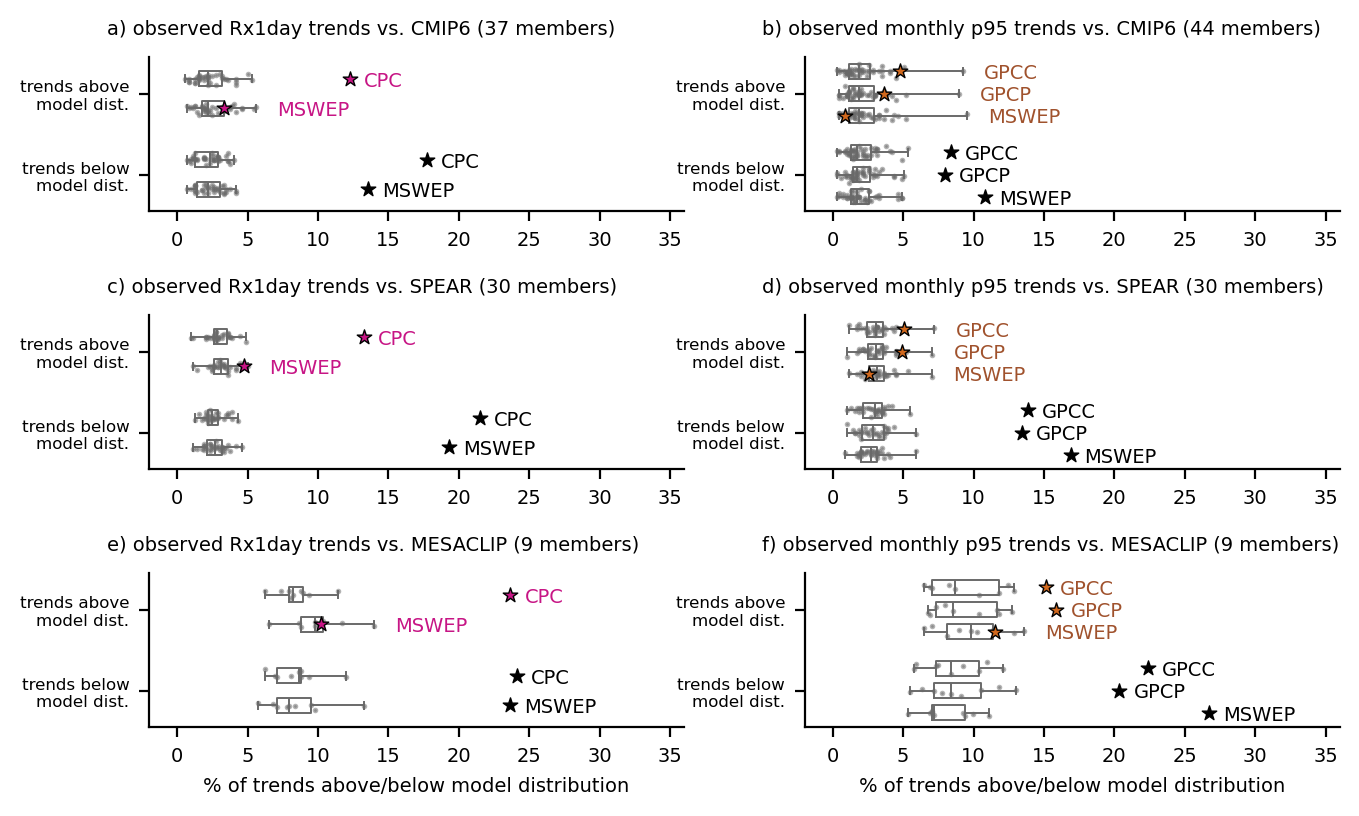

In [100]:
fig = plt.figure(figsize = (6.69, 4.3)) ## can be up to 170mm wide

XMAX = 36
ax = fig.add_axes([0.1, 0.7, 0.4, 0.18])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 0.95, 'a) observed Rx1day trends vs. CMIP6 (37 members)', size = 7)
## positive trends
bp = plot_box_points(ecdf_test_cpc_cmipsub_day.pos_ecdf_1+ecdf_test_cpc_cmipsub_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_cmipsub_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_day.pos_ecdf_1+ecdf_test_mswep_cmipsub_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_cmipsub_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_cmipsub_day.pos_ecdf_0+ecdf_test_cpc_cmipsub_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_cmipsub_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_day.pos_ecdf_0+ecdf_test_mswep_cmipsub_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_cmipsub_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.1, 0.4, 0.4, 0.18])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 0.95, 'c) observed Rx1day trends vs. SPEAR (30 members)', size = 7)
bp = plot_box_points(ecdf_test_cpc_spear_day.pos_ecdf_1+ecdf_test_cpc_spear_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_spear_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_spear_day.pos_ecdf_1+ecdf_test_mswep_spear_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_spear_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_spear_day.pos_ecdf_0+ecdf_test_cpc_spear_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_spear_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_spear_day.pos_ecdf_0+ecdf_test_mswep_spear_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_spear_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.1, 0.1, 0.4, 0.18])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 0.95, 'e) observed Rx1day trends vs. MESACLIP (9 members)', size = 7)
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_1+ecdf_test_cpc_mesaclip_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_mesaclip_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_1+ecdf_test_mswep_mesaclip_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_mesaclip_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_0+ecdf_test_cpc_mesaclip_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_mesaclip_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_0+ecdf_test_mswep_mesaclip_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_mesaclip_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax.set_xlabel("% of trends above/below model distribution", size = 7)

ax = fig.add_axes([0.59, 0.7, 0.4, 0.18])
ax.text(-5, 0.95, 'b) observed monthly p95 trends vs. CMIP6 (44 members)', size = 7)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_cmipsub_mon.pos_ecdf_1+ecdf_test_gpcc_cmipsub_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_cmipsub_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_cmipsub_mon.pos_ecdf_1+ecdf_test_gpcp_cmipsub_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_cmipsub_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col) 
bp = plot_box_points(ecdf_test_mswep_cmipsub_mon.pos_ecdf_1+ecdf_test_mswep_cmipsub_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_cmipsub_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_cmipsub_mon.pos_ecdf_0+ecdf_test_gpcc_cmipsub_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_cmipsub_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_cmipsub_mon.pos_ecdf_0+ecdf_test_gpcp_cmipsub_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_cmipsub_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_mon.pos_ecdf_0+ecdf_test_mswep_cmipsub_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_cmipsub_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.59, 0.4, 0.4, 0.18])
ax.text(-5, 0.95, 'd) observed monthly p95 trends vs. SPEAR (30 members)', size = 7)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_spear_mon.pos_ecdf_1+ecdf_test_gpcc_spear_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_spear_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_spear_mon.pos_ecdf_1+ecdf_test_gpcp_spear_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_spear_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col) 
bp = plot_box_points(ecdf_test_mswep_spear_mon.pos_ecdf_1+ecdf_test_mswep_spear_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_spear_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_spear_mon.pos_ecdf_0+ecdf_test_gpcc_spear_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_spear_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_spear_mon.pos_ecdf_0+ecdf_test_gpcp_spear_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_spear_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_spear_mon.pos_ecdf_0+ecdf_test_mswep_spear_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_spear_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 
plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.59, 0.1, 0.4, 0.18])
ax.text(-5, 0.95, 'f) observed monthly p95 trends vs. MESACLIP (9 members)', size = 7)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_mesaclip_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_mesaclip_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col)
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_1+ecdf_test_mswep_mesaclip_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_mesaclip_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_mesaclip_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_mesaclip_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_0+ecdf_test_mswep_mesaclip_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_mesaclip_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);
ax.set_xlabel("% of trends above/below model distribution", size = 7)

plt.savefig("../figures/fig3.pdf")
plt.savefig("../figures/fig3.png", dpi = 600)

### 9 member ensemble comparison

In [82]:
def add_box_label(label, color, position, bp):
    label_position = bp['caps'][1].get_xdata()[0] + 1.5
    ax.text(label_position, position-0.05, label, size = 7, color = color, ha = "left")

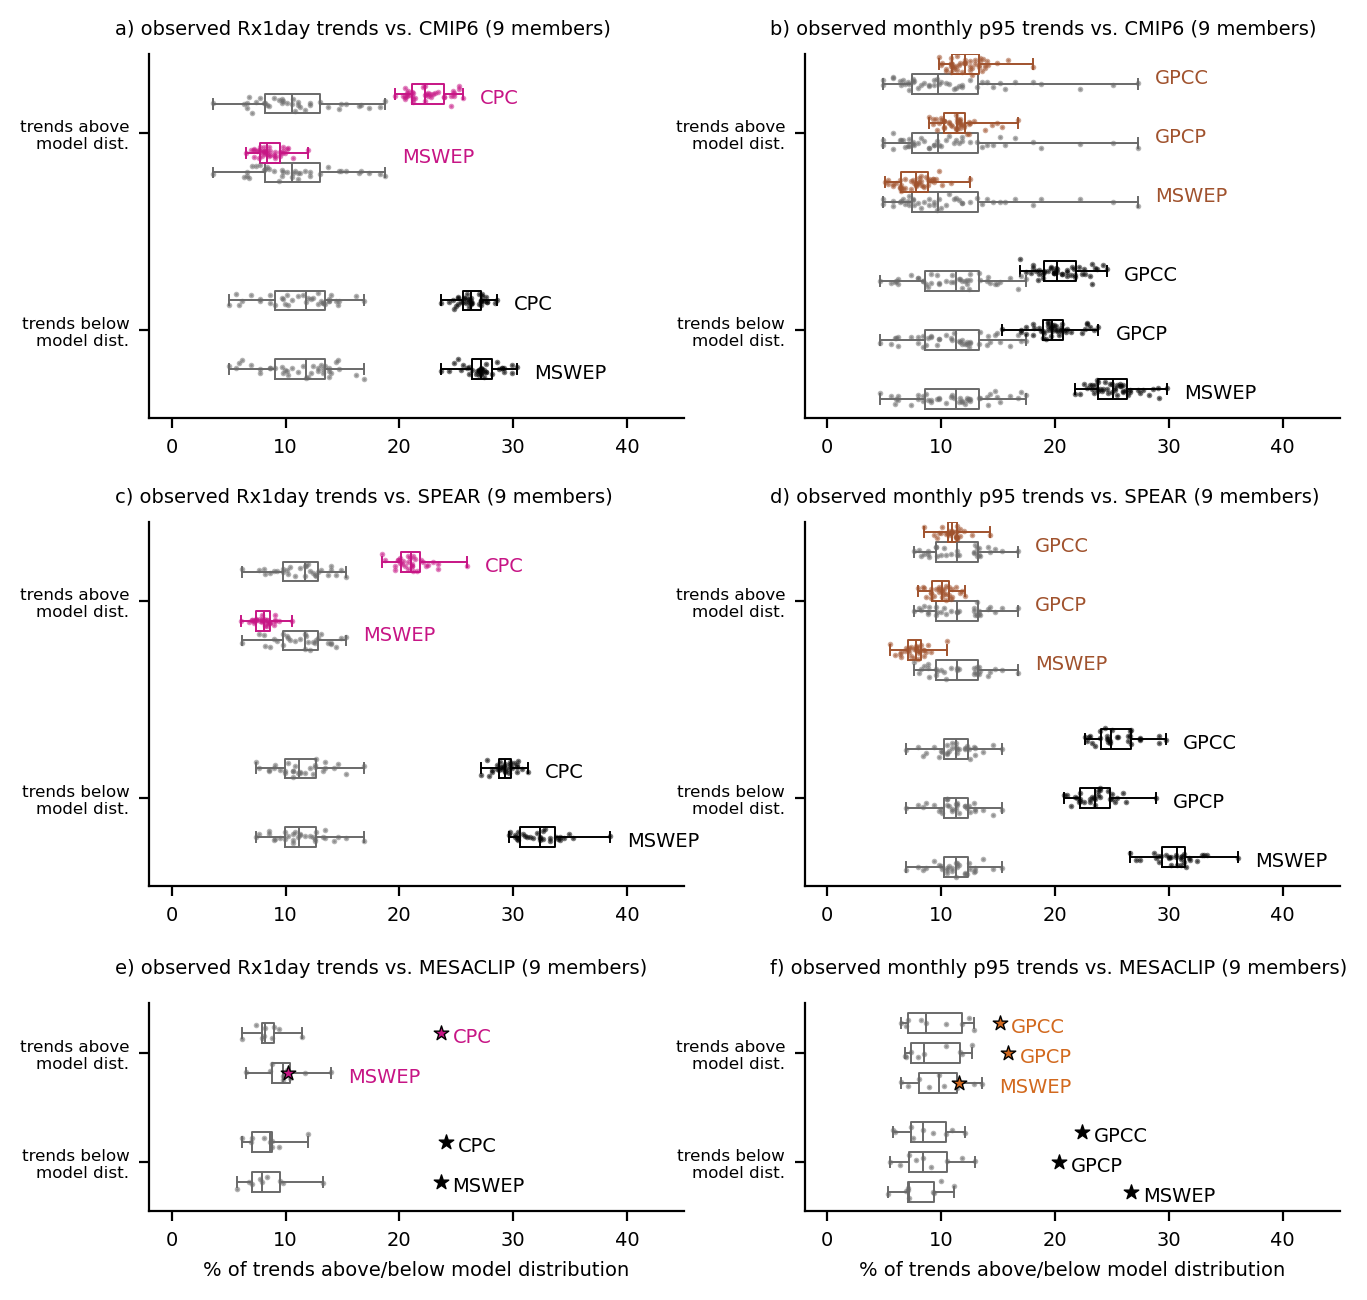

In [103]:
fig = plt.figure(figsize = (6.69, 6.5)) ## can be up to 170mm wide

XMAX = 45
ax = fig.add_axes([0.1, 0.69, 0.4, 0.28])
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 1.7, 'a) observed Rx1day trends vs. CMIP6 (9 members)', size = 7)
## positive trends
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.sim_pos_ecdf_1+ecdf_sub9_cpc_cmip_day.sim_neg_ecdf_1, N, position = 1.35)
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.obs_pos_ecdf_1+ecdf_sub9_cpc_cmip_day.obs_neg_ecdf_1, N, position = 1.4, 
                box_color = day_pos_col, point_color = day_pos_col)
add_box_label("CPC", day_pos_col, 1.4, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.sim_pos_ecdf_1+ecdf_sub9_mswep_cmip_day.sim_neg_ecdf_1, N, position = 1)
plot_box_points(ecdf_sub9_mswep_cmip_day.obs_pos_ecdf_1+ecdf_sub9_mswep_cmip_day.obs_neg_ecdf_1, N, position = 1.1,
                    box_color = day_pos_col, point_color = day_pos_col)
add_box_label("MSWEP", day_pos_col, 1.1, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.sim_pos_ecdf_0+ecdf_sub9_cpc_cmip_day.sim_neg_ecdf_0, N, position = 0.35) 
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.obs_pos_ecdf_0+ecdf_sub9_cpc_cmip_day.obs_neg_ecdf_0, N, position = 0.35, box_color = "black", point_color = "black")
add_box_label("CPC", neg_col, 0.35, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.sim_pos_ecdf_0+ecdf_sub9_mswep_cmip_day.sim_neg_ecdf_0, N, position = 0)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.obs_pos_ecdf_0+ecdf_sub9_mswep_cmip_day.obs_neg_ecdf_0, N, position = 0, box_color = "black", point_color = "black")
add_box_label("MSWEP", neg_col, 0, bp)

plt.yticks([0.2, 1.2], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.1, 0.33, 0.4, 0.28])
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 1.7, 'c) observed Rx1day trends vs. SPEAR (9 members)', size = 7)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.sim_pos_ecdf_1+ecdf_sub9_cpc_spear_day.sim_neg_ecdf_1, N, position = 1.35)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.obs_pos_ecdf_1+ecdf_sub9_cpc_spear_day.obs_neg_ecdf_1, N, position = 1.4, box_color = day_pos_col, point_color = day_pos_col)
add_box_label("CPC", day_pos_col, 1.4, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.sim_pos_ecdf_1+ecdf_sub9_mswep_spear_day.sim_neg_ecdf_1, N, position = 1)
plot_box_points(ecdf_sub9_mswep_spear_day.obs_pos_ecdf_1+ecdf_sub9_mswep_spear_day.obs_neg_ecdf_1, N, position = 1.1, box_color = day_pos_col, point_color = day_pos_col)
add_box_label("MSWEP", day_pos_col, 1.05, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_cpc_spear_day.sim_pos_ecdf_0+ecdf_sub9_cpc_spear_day.sim_neg_ecdf_0, N, position = 0.35)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.obs_pos_ecdf_0+ecdf_sub9_cpc_spear_day.obs_neg_ecdf_0, N, position = 0.35, box_color = "black", point_color = "black")
add_box_label("CPC", "black", 0.35, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.sim_pos_ecdf_0+ecdf_sub9_mswep_spear_day.sim_neg_ecdf_0, N, position = 0)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.obs_pos_ecdf_0+ecdf_sub9_mswep_spear_day.obs_neg_ecdf_0, N, position = 0, box_color = "black", point_color = "black") 
add_box_label("MSWEP", "black", 0, bp)

plt.yticks([0.2, 1.2], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.1, 0.08, 0.4, 0.16])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-5, 0.95, 'e) observed Rx1day trends vs. MESACLIP (9 members)', size = 7)
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_1+ecdf_test_cpc_mesaclip_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_mesaclip_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_1+ecdf_test_mswep_mesaclip_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_mesaclip_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_0+ecdf_test_cpc_mesaclip_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_mesaclip_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_0+ecdf_test_mswep_mesaclip_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_mesaclip_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax.set_xlabel("% of trends above/below model distribution", size = 7)

ax = fig.add_axes([0.59, 0.69, 0.4, 0.28])
ax.text(-5, 1.7, 'b) observed monthly p95 trends vs. CMIP6 (9 members)', size = 7)
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_gpcc_cmip_mon.sim_neg_ecdf_1, N, position = 1.45)
plot_box_points(ecdf_sub9_gpcc_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_gpcc_cmip_mon.obs_neg_ecdf_1, N, position = 1.55, box_color = "sienna", point_color = "sienna")
add_box_label("GPCC", "sienna", 1.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_gpcp_cmip_mon.sim_neg_ecdf_1, N, position = 1.15)
plot_box_points(ecdf_sub9_gpcp_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_gpcp_cmip_mon.obs_neg_ecdf_1, N, position = 1.25, box_color = "sienna", point_color = "sienna")
add_box_label("GPCP", "sienna", 1.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_mswep_cmip_mon.sim_neg_ecdf_1, N, position = 0.85)
plot_box_points(ecdf_sub9_mswep_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_mswep_cmip_mon.obs_neg_ecdf_1, N, position = 0.95, box_color = "sienna", point_color = "sienna")
add_box_label("MSWEP", "sienna", 0.9, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_gpcc_cmip_mon.sim_neg_ecdf_0, N, position = 0.45)
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_gpcc_cmip_mon.obs_neg_ecdf_0, N, position = 0.5, box_color = "black", point_color = "black")
add_box_label("GPCC", "black", 0.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_gpcp_cmip_mon.sim_neg_ecdf_0, N, position = 0.15)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_gpcp_cmip_mon.obs_neg_ecdf_0, N, position = 0.2, box_color = "black", point_color = "black")
add_box_label("GPCP", "black", 0.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_mswep_cmip_mon.sim_neg_ecdf_0, N, position = -0.15)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_mswep_cmip_mon.obs_neg_ecdf_0, N, position = -0.1, box_color = "black", point_color = "black")
add_box_label("MSWEP", "black", -0.1, bp)

plt.yticks([0.2, 1.2], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.59, 0.33, 0.4, 0.28])
ax.text(-5, 1.7, 'd) observed monthly p95 trends vs. SPEAR (9 members)', size = 7)
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.sim_pos_ecdf_1+ecdf_sub9_gpcc_spear_mon.sim_neg_ecdf_1, N, position = 1.45)
plot_box_points(ecdf_sub9_gpcc_spear_mon.obs_pos_ecdf_1+ecdf_sub9_gpcc_spear_mon.obs_neg_ecdf_1, N, position = 1.55, box_color = "sienna", point_color = "sienna")
add_box_label("GPCC", "sienna", 1.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.sim_pos_ecdf_1+ecdf_sub9_gpcp_spear_mon.sim_neg_ecdf_1, N, position = 1.15)
plot_box_points(ecdf_sub9_gpcp_spear_mon.obs_pos_ecdf_1+ecdf_sub9_gpcp_spear_mon.obs_neg_ecdf_1, N, position = 1.25, box_color = "sienna", point_color = "sienna")
add_box_label("GPCP", "sienna", 1.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.sim_pos_ecdf_1+ecdf_sub9_mswep_spear_mon.sim_neg_ecdf_1, N, position = 0.85)
plot_box_points(ecdf_sub9_mswep_spear_mon.obs_pos_ecdf_1+ecdf_sub9_mswep_spear_mon.obs_neg_ecdf_1, N, position = 0.95, box_color = "sienna", point_color = "sienna")
add_box_label("MSWEP", "sienna", 0.9, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.sim_pos_ecdf_0+ecdf_sub9_gpcc_spear_mon.sim_neg_ecdf_0, N, position = 0.45)
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.obs_pos_ecdf_0+ecdf_sub9_gpcc_spear_mon.obs_neg_ecdf_0, N, position = 0.5, box_color = "black", point_color = "black")
add_box_label("GPCC", "black", 0.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.sim_pos_ecdf_0+ecdf_sub9_gpcp_spear_mon.sim_neg_ecdf_0, N, position = 0.15)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.obs_pos_ecdf_0+ecdf_sub9_gpcp_spear_mon.obs_neg_ecdf_0, N, position = 0.2, box_color = "black", point_color = "black")
add_box_label("GPCP", "black", 0.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.sim_pos_ecdf_0+ecdf_sub9_mswep_spear_mon.sim_neg_ecdf_0, N, position = -0.15)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.obs_pos_ecdf_0+ecdf_sub9_mswep_spear_mon.obs_neg_ecdf_0, N, position = -0.1, box_color = "black", point_color = "black")
add_box_label("MSWEP", "black", -0.1, bp)
plt.yticks([0.2, 1.2], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);

ax = fig.add_axes([0.59, 0.08, 0.4, 0.16])
ax.text(-5, 0.95, 'f) observed monthly p95 trends vs. MESACLIP (9 members)', size = 7)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_mesaclip_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_mesaclip_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP")
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_1+ecdf_test_mswep_mesaclip_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_mesaclip_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_mesaclip_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_mesaclip_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_0+ecdf_test_mswep_mesaclip_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_mesaclip_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends below\nmodel dist.", "trends above\nmodel dist."], size = 6);
ax.set_xlabel("% of trends above/below model distribution", size = 7)

plt.savefig("../figures/supp_9member_comparison.pdf")
plt.savefig("../figures/supp_9member_comparison.png", dpi = 600)

### time series plots

In [51]:
def calc_ecdf(start, ens = "sub"):
    print(start)
    end = 2020
    trend = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
    stat = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
    trend_sd = (trend.sel(predictions = "coeff").value*(end-start+1))/stat.p95*100

    files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
    mtrend = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mtrend.append(x)
    mtrend = xr.concat(mtrend, dim = "model_variant")

    files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(start+39)+"_stats.nc"))
    mstat = []
    for f in files:
        x = xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]})
        try:
            x = x.drop_vars("type")
        except:
            y = 0
        mstat.append(x)
    mstat = xr.concat(mstat, dim = "model_variant", coords = "minimal")

    mtrend_sd = (mtrend.sel(predictions = "coeff").value*(end-start+1))/mstat.p95*100

    if ens == "full":
        ecdf_dat = ecdf_xr(mtrend_sd, 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))
    elif ens == "sub": 
        ecdf_dat = ecdf_xr(mtrend_sd.sel(model_variant = onevar_model_keys), 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))

    ## number of positive trends (in each time period)
    summary_dat = pd.DataFrame({"start_year": [start], 
                                "pos_trends": (trend_sd > 0).sum().values,
                                "neg_trends": (trend_sd < 0).sum().values, 
                                "ecdf_1": ((trend_sd > 0) & (ecdf_dat == 1)).sum().values,
                                "ecdf_97.5": ((trend_sd > 0) & (ecdf_dat >= 0.975)).sum().values,
                                "ecdf_0": ((trend_sd < 0) & (ecdf_dat == 0)).sum().values,
                                "ecdf_025": ((trend_sd < 0) & (ecdf_dat <= 0.025)).sum().values, 
                                "ens_mean_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).mean(dim = "model_variant").values,
                                "ens_max_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).max(dim = "model_variant").values,
                                "ens_min_pos":(mtrend_sd > 0).sum(dim = ["lat", "lon"]).min(dim = "model_variant").values})

    return(ecdf_dat, summary_dat)

In [52]:
ecdf_alldates = []
summary_dat = []
for s in np.arange(1930, 1985, 5):
    a, b = calc_ecdf(s, ens = "sub")
    ecdf_alldates.append(a.assign_coords({"start_year": s}))
    summary_dat.append(b)

ecdf_alldates = xr.concat(ecdf_alldates, dim = "start_year", coords = "minimal")
summary_dat = pd.concat(summary_dat)

1930
1935
1940
1945
1950
1955
1960
1965
1970
1975
1980


In [53]:
summary_dat

,start_year,pos_trends,neg_trends,ecdf_1,ecdf_97.5,ecdf_0,ecdf_025,ens_mean_pos,ens_max_pos,ens_min_pos
0,1930,470,243,0,0,64,100,251.943953,602,0
0,1935,444,269,0,0,81,124,254.879056,604,0
0,1940,431,282,0,0,80,116,257.575221,611,0
0,1945,434,279,0,0,89,128,261.283186,604,0
0,1950,414,299,0,0,102,140,265.554572,607,0
0,1955,399,314,0,0,94,139,269.501475,614,0
0,1960,390,323,0,0,70,105,488.427729,611,0
0,1965,402,311,0,0,68,100,490.528024,603,0
0,1970,410,303,0,0,59,97,493.894602,601,0
0,1975,392,321,0,0,61,100,487.843188,591,0


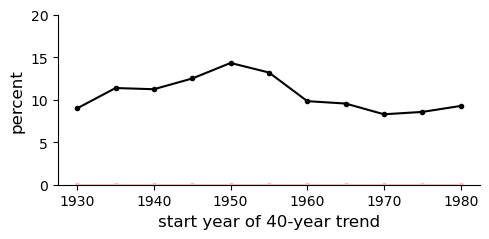

In [54]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_0)/713*100, 
        marker = ".", color = "black")
ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_1)/713*100, 
        marker = ".", color = "pink")

ax.set(ylim = (0,20))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

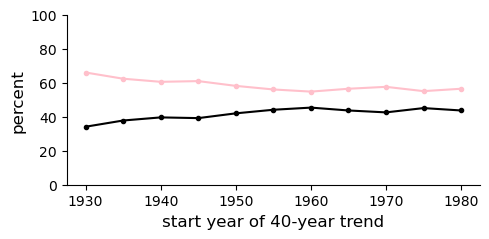

In [55]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.pos_trends)/713*100, 
        marker = ".", color = "pink")
ax.plot(summary_dat.start_year, 
        (summary_dat.neg_trends)/713*100, 
        marker = ".", color = "black")

ax.set(ylim = (0,100))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()